# Plot from Database Example

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine
from sqlmodel import Session, select

from cali.sqlmodel import ROI, Traces
from cali.sqlmodel._model import CaliResult

In [ ]:
# database_path = "/Users/fdrgsp/Documents/git/cali/tests/test_data/data_and_db_for_tests/test_db.cali"  # noqa: E501
database_path = "/Volumes/T7 Shield/for FG/TSC_hSynLAM77_ACTX250730_D36/results.cali"
engine = create_engine(f"sqlite:///{database_path}")

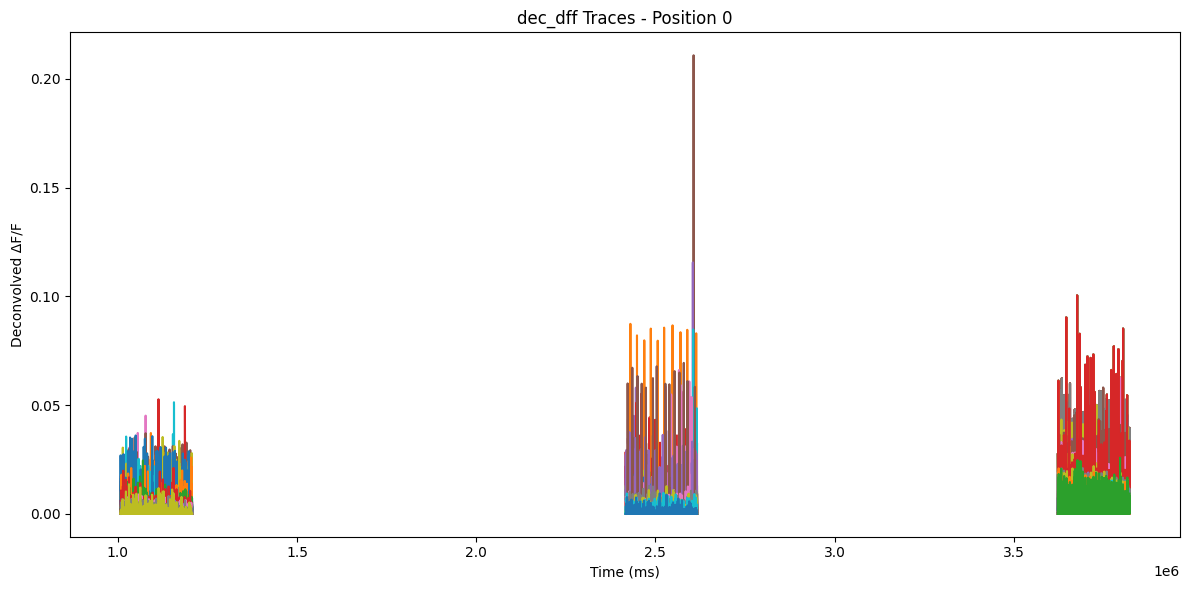

In [3]:
with Session(engine) as session:
    # Filter by detection settings ID (use None to get all)
    # Change this to filter by specific detection settings, or setto None for all
    detection_id = 1

    statement = select(Traces).join(ROI, Traces.roi_id == ROI.id)

    if detection_id is not None:
        statement = statement.join(CaliResult).where(
            CaliResult.detection_settings_id == detection_id
        )

    traces_list = session.exec(statement).all()

    # Plot all dec_dff traces
    fig, ax = plt.subplots(figsize=(12, 6))

    for trace in traces_list:
        tr = trace
        if trace.inferred_spikes is not None:
            # Use x_axis if available, otherwise use frame numbers
            x_data = (
                trace.x_axis
                if trace.x_axis is not None
                else list(range(len(trace.dec_dff)))
            )
            ax.plot(
                x_data,
                trace.inferred_spikes,
                # label=f"ROI {trace.roi.label_value}",
                # alpha=0.7,
            )

    x_label = "Time (ms)" if traces_list and traces_list[0].x_axis else "Frame"
    ax.set_xlabel(x_label)
    ax.set_ylabel("Deconvolved ΔF/F")
    ax.set_title("dec_dff Traces - Position 0")
    # ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

spike_times: [  4  53 103]

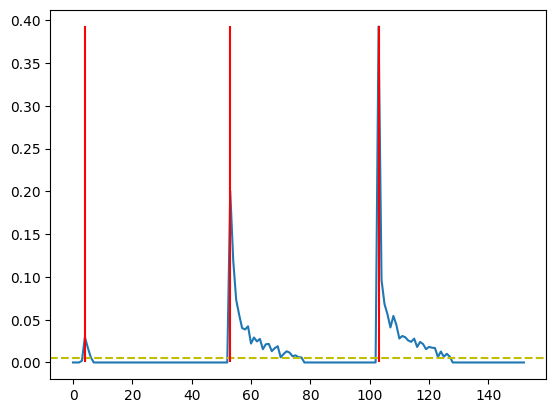

In [16]:
tr = traces_list[1]
inferred = np.asarray(tr.inferred_spikes, dtype=float)
th = 0.005
above = inferred > th
rising = above & ~np.concatenate(([False], above[:-1]))
spike_times = np.where(rising)[0]
print("spike_times:", spike_times)

t = np.arange(len(inferred))
plt.plot(t, inferred)
plt.axhline(th, ls="--", color="y")
plt.vlines(spike_times, inferred.min(), inferred.max(), color="r")
plt.show()

In [ ]:
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
from cali.analysis._util import (
    _compute_zero_lag_corr_matrix,
    _get_spike_correlations_matrix,
)
from sqlalchemy import create_engine
from sqlmodel import Session, select

from cali.sqlmodel import ROI, Traces
from cali.sqlmodel._model import CaliResult

database_path = "/Volumes/T7 Shield/for FG/TSC_hSynLAM77_ACTX250730_D36/results.cali"
engine = create_engine(f"sqlite:///{database_path}")


def query_traces(
    run_id: int,
    selected_roi_labels: list[str] | None,
    trace_type: Literal["raw_trace", "dff", "dec_dff", "inferred_spikes"] = "dec_dff",
    plot: bool = True,
) -> list[np.ndarray]:
    """Query traces from the database and optionally plot them."""
    if trace_type not in ["raw_trace", "dff", "dec_dff", "inferred_spikes"]:
        raise ValueError(f"Invalid trace_type: {trace_type}")

    with Session(engine) as session:
        # Control variables
        # Change this to select different analysis runs
        run_id = run_id
        # Set to list of ROI labels (e.g., ["ROI_001", "ROI_002"]) or None for all ROIs
        # selected_roi_labels = ["ROI_001", "ROI_002", "ROI_003"]
        selected_roi_labels = selected_roi_labels

        statement = select(Traces).join(ROI, Traces.roi_id == ROI.id)

        # Filter by run/analysis result ID
        if run_id is not None:
            statement = statement.where(Traces.analysis_result_id == run_id)

        # Filter by specific ROI labels if provided
        if selected_roi_labels is not None:
            statement = statement.where(ROI.label_value.in_(selected_roi_labels))

        traces_list = session.exec(statement).all()

        # roi label: trace value list of float

        # Plot all inferred spikes traces
        if plot:
            _fig, ax = plt.subplots(figsize=(12, 6))
        traces_arrays = []
        for trace in traces_list:
            tr = None
            if trace_type == "raw_trace" and trace.raw_trace is not None:
                traces_arrays.append(np.array(trace.raw_trace))
                tr = trace.raw_trace
            elif trace_type == "dff" and trace.dff is not None:
                traces_arrays.append(np.array(trace.dff))
                tr = trace.dff
            elif trace_type == "dec_dff" and trace.dec_dff is not None:
                traces_arrays.append(np.array(trace.dec_dff))
                tr = trace.dec_dff
            elif trace_type == "inferred_spikes" and trace.inferred_spikes is not None:
                traces_arrays.append(np.array(trace.inferred_spikes))
                tr = trace.inferred_spikes
            else:
                continue
            if not plot:
                continue
            x_data = trace.x_axis if trace.x_axis is not None else list(range(len(tr)))
            ax.plot(x_data, tr, alpha=0.7)
        if plot:
            plt.tight_layout()
            plt.show()

        return traces_arrays

ROIs:
[1, 2, 3, 4, 5, 6, 7, 8, 9]

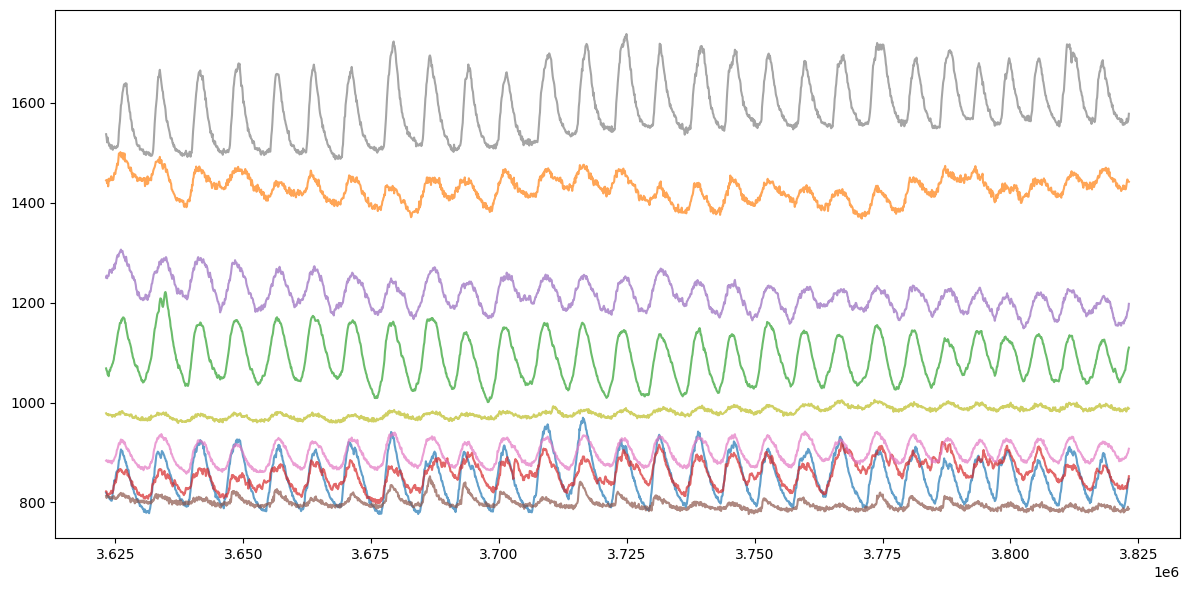

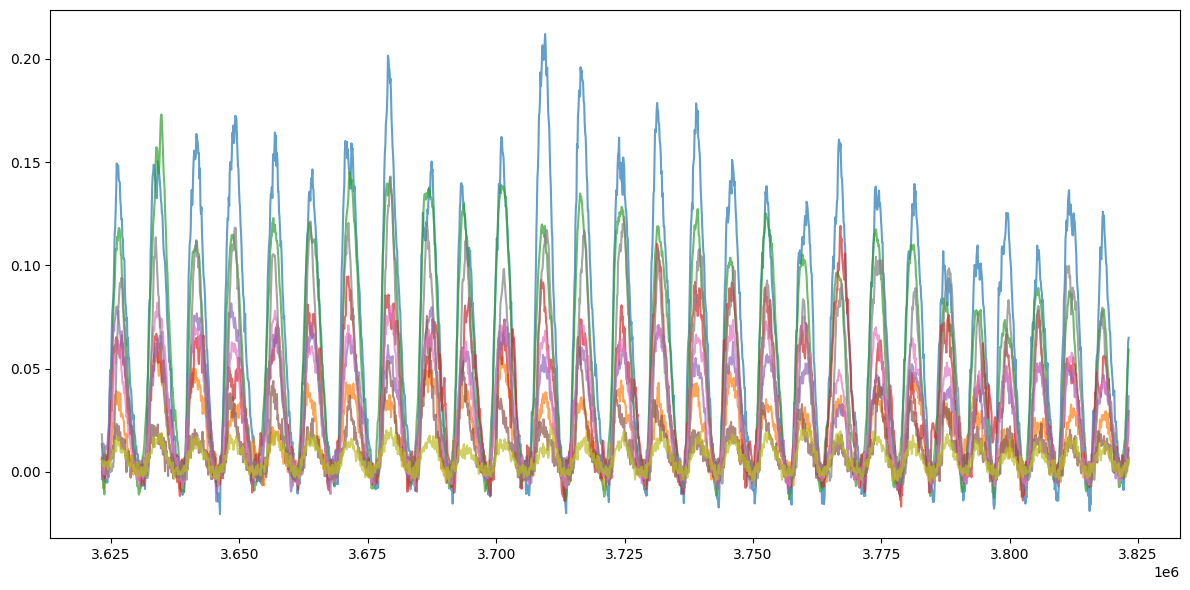

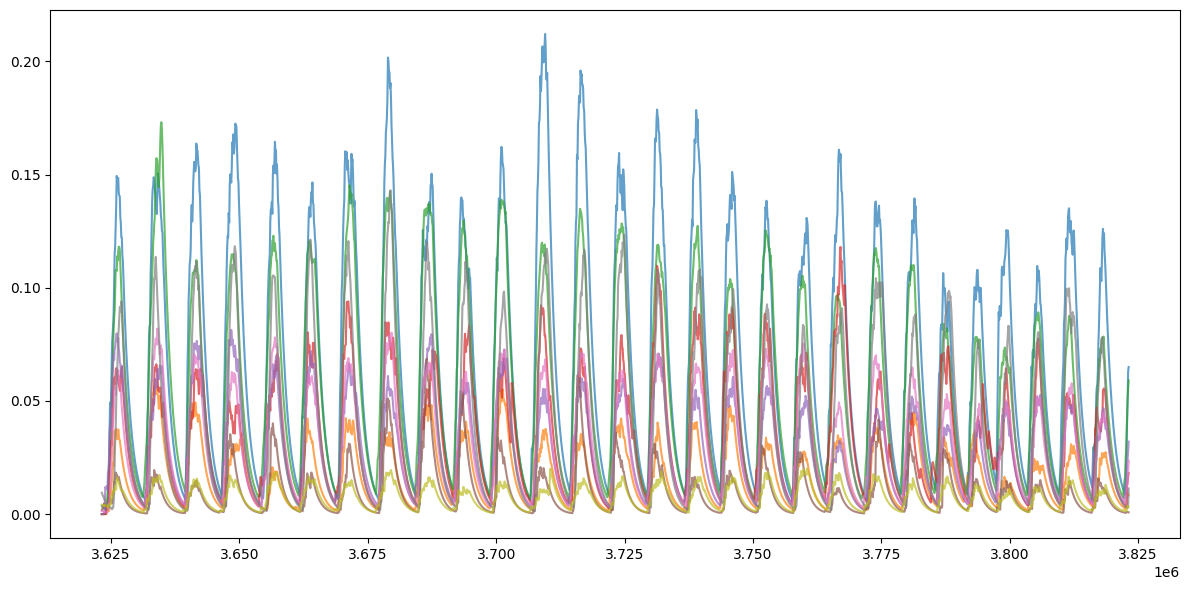

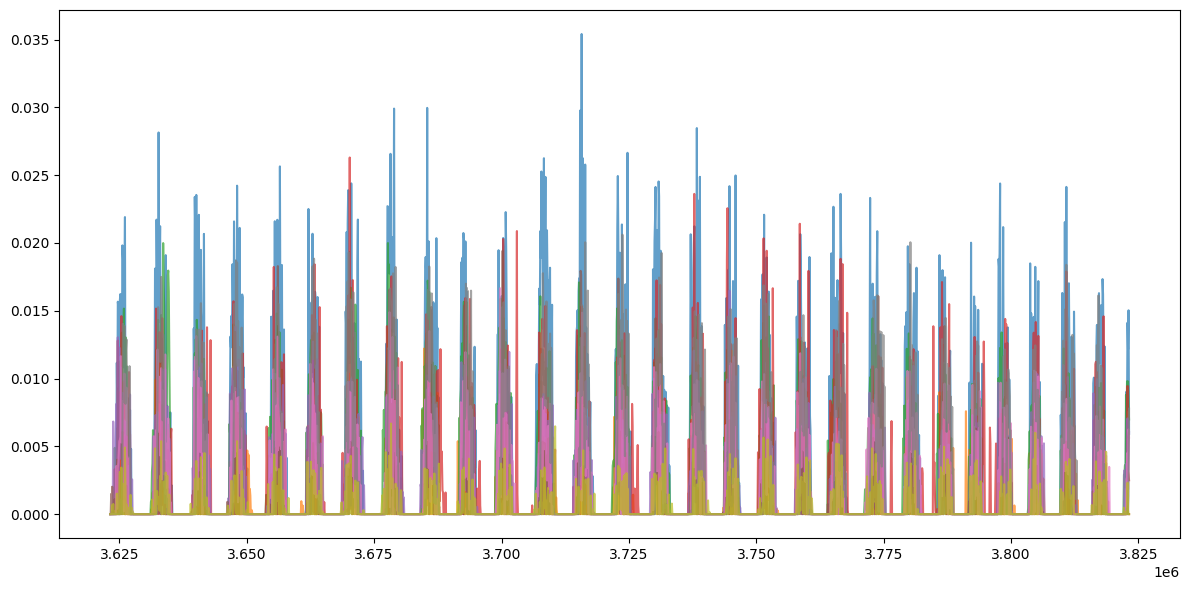

In [ ]:
rois = list(range(1, 10))
print("ROIs:", rois)
raw = query_traces(5, rois, "raw_trace")
dff = query_traces(5, rois, "dff")
dec_dff = query_traces(5, rois, "dec_dff")
spikes = query_traces(5, rois, "inferred_spikes")

In [ ]:
pearsons_matrix_raw = _compute_zero_lag_corr_matrix(raw)
pearsons_matrix_dff = _compute_zero_lag_corr_matrix(dff)
pearsons_matrix_dec_dff = _compute_zero_lag_corr_matrix(dec_dff)  # ***
pearsons_matrix_spikes = _compute_zero_lag_corr_matrix(spikes)

In [ ]:
print("Median Pearson's correlation (raw):", np.median(pearsons_matrix_raw))
print("Median Pearson's correlation (dff):", np.median(pearsons_matrix_dff))
print("Median Pearson's correlation (dec_dff):", np.median(pearsons_matrix_dec_dff))
print("Median Pearson's correlation (spikes):", np.median(pearsons_matrix_spikes))

Median Pearson's correlation (raw): 0.66085405012272

Median Pearson's correlation (dff): 0.863082661448399

Median Pearson's correlation (dec_dff): 0.8667214322057063

Median Pearson's correlation (spikes): 0.4970352743227487

In [ ]:
pearsons_matrix_spikes_1 = _get_spike_correlations_matrix()